# Orbit Examples

This notebook gives some detailed orbit examples,
including the eccentricity distribution of thick-disk stars, integrating the LMC orbit with dynamical friction, and taking the barycentric acceleration
due to the LMC into account for Milky-Way orbits.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy
import copy
from astropy import units
from matplotlib import pyplot as plt
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, ChandrasekharDynamicalFrictionForce
from galpy.util import conversion

## The eccentricity distribution of the Milky Way's thick disk

A straightforward application of galpy's orbit-integration capabilities is to
derive the eccentricity distribution for a set of thick-disk stars. We use the
SDSS/SEGUE thick-disk sample compiled by
[Dierickx et al. (2010)](https://ui.adsabs.harvard.edu/abs/2010ApJ...725L.186D/abstract),
which we download from Vizier:

In [2]:
import os

from astropy.table import Table

from galpy.potential import LogarithmicHaloPotential

# Cache the Vizier query result locally so re-runs of this notebook don't
# repeat the catalog download, which is occasionally slow or unavailable.
_dierickx_cache = "dierickx_2010_thick_disk.fits"

if os.path.exists(_dierickx_cache):
    dierickx = Table.read(_dierickx_cache)
    print(
        f"Loaded {len(dierickx)} thick-disk stars from local cache: {_dierickx_cache}"
    )
else:
    from astroquery.vizier import Vizier

    v = Vizier(columns=["*"], row_limit=-1)
    result = v.get_catalogs("J/ApJ/725/L186")
    dierickx = result["J/ApJ/725/L186/table2"]
    print(f"Downloaded {len(dierickx)} thick-disk stars")
    dierickx.write(_dierickx_cache, format="fits", overwrite=True)

Downloaded 31535 thick-disk stars


Set up the phase-space coordinates as `(RA, Dec, distance, pmRA, pmDec, vlos)`
and initialize orbits in a `LogarithmicHaloPotential` (a spherical potential with
a flat rotation curve). All stars are formally bound in this potential
(which has an infinite escape velocity), but a handful have such extreme
kinematics that their orbits cause numerical issues, so we filter those out:

In [3]:
vxvv = numpy.column_stack(
    [
        numpy.array(dierickx["RAJ2000"], dtype=float),
        numpy.array(dierickx["DEJ2000"], dtype=float),
        numpy.array(dierickx["Dist"], dtype=float) / 1e3,  # pc -> kpc
        numpy.array(dierickx["pmRA"], dtype=float),
        numpy.array(dierickx["pmDE"], dtype=float),
        numpy.array(dierickx["HRV"], dtype=float),
    ]
)

lp = LogarithmicHaloPotential(normalize=1.0)
all_orbits = Orbit(vxvv, radec=True, ro=8.0, vo=220.0, solarmotion="hogg")

# Filter out stars with extreme energies that cause numerical issues
E = all_orbits.E(pot=lp, use_physical=False)
keep = E < 3.0
orbits = all_orbits[keep]
e_dierickx = numpy.array(dierickx["e"], dtype=float)[keep]
print(
    f"Keeping {keep.sum()} of {len(keep)} orbits (removed {(~keep).sum()} extreme outliers)"
)

Keeping 31491 of 31535 orbits (removed 44 extreme outliers)


Now we compute eccentricities in two ways: (a) by integrating each orbit for
many dynamical times and finding the actual peri- and apocenter, and (b)
analytically using the [Staeckel approximation](./fast_characterization.ipynb),
which avoids orbit integration entirely:

In [4]:
# Analytic eccentricities (Staeckel approximation, very fast)
e_ana = orbits.e(analytic=True, pot=lp, delta=0.01)

# Numerical eccentricities (orbit integration)
ts = numpy.linspace(0.0, 20.0, 1001)
orbits.integrate(ts, lp)
e_int = orbits.e()

The eccentricity distribution of the thick disk peaks around $e \approx 0.25$:

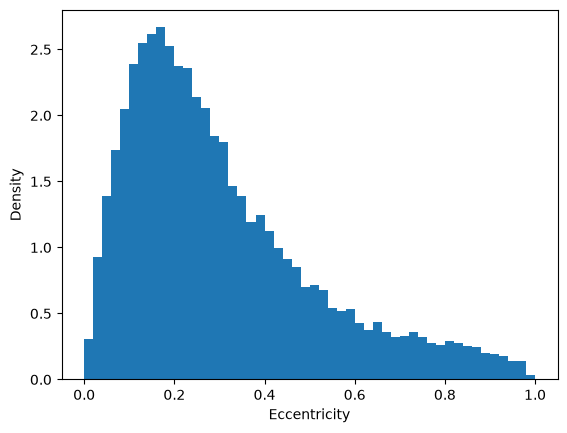

In [5]:
plt.hist(e_int, bins=50, range=(0, 1), density=True)
plt.xlabel(r"$\mathrm{Eccentricity}$")
plt.ylabel(r"$\mathrm{Density}$");

We can compare galpy's integrated eccentricities with those published by
Dierickx et al. (2010). The agreement is excellent for most stars:

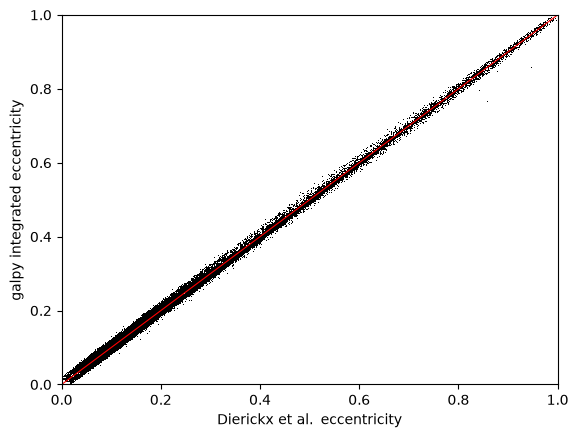

In [6]:
plt.plot(e_dierickx, e_int, "k,")
plt.plot([0, 1], [0, 1], "r-", lw=0.8)
plt.xlabel(r"$\mathrm{Dierickx\ et\ al.\ eccentricity}$")
plt.ylabel(r"$\mathrm{galpy\ integrated\ eccentricity}$")
plt.xlim(0, 1)
plt.ylim(0, 1);

The analytic Staeckel estimates are equally good:

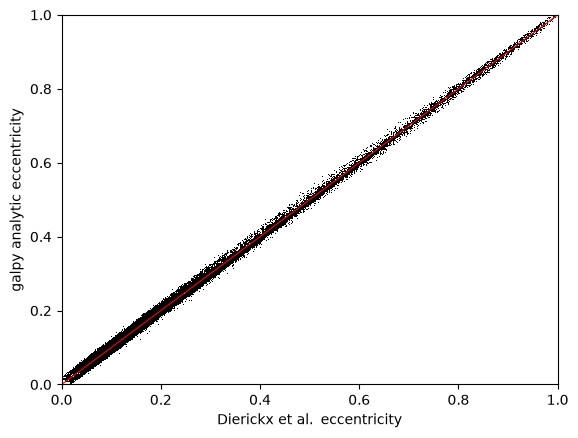

In [7]:
plt.plot(e_dierickx, e_ana, "k,")
plt.plot([0, 1], [0, 1], "r-", lw=0.8)
plt.xlabel(r"$\mathrm{Dierickx\ et\ al.\ eccentricity}$")
plt.ylabel(r"$\mathrm{galpy\ analytic\ eccentricity}$")
plt.xlim(0, 1)
plt.ylim(0, 1);

Because the `LogarithmicHaloPotential` is spherical, the Staeckel
approximation is essentially exact. Comparing the integrated and analytic
eccentricities directly confirms this:

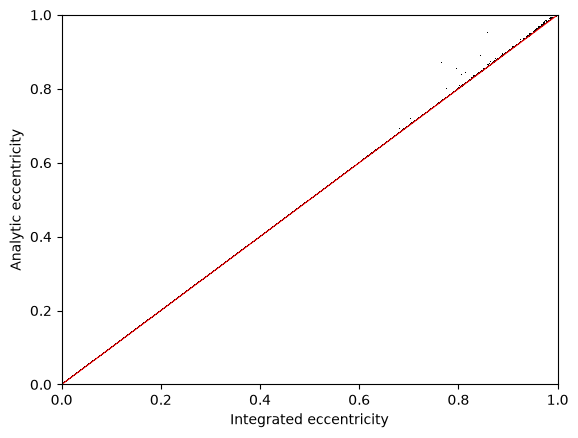

In [8]:
plt.plot(e_int, e_ana, "k,")
plt.plot([0, 1], [0, 1], "r-", lw=0.8)
plt.xlabel(r"$\mathrm{Integrated\ eccentricity}$")
plt.ylabel(r"$\mathrm{Analytic\ eccentricity}$")
plt.xlim(0, 1)
plt.ylim(0, 1);

## LMC orbit with dynamical friction

The Large Magellanic Cloud (LMC) is a massive satellite of the Milky Way, so its
orbit is significantly affected by dynamical friction -- a frictional force of
gravitational origin that occurs when a massive object travels through a sea of
low-mass objects (halo stars and dark matter; see Section 19.4.1 in [galaxiesbook.org](https://galaxiesbook.org/chapters/IV-03.-Hierarchical-Galaxy-Formation_4-Dynamical-processes.html#Dynamical-friction)). We investigate the LMC's past and
future orbit using `ChandrasekharDynamicalFrictionForce`.

First, we load the current phase-space coordinates for the LMC using `Orbit.from_name`.
Because the LMC is unbound in the default ``MWPotential2014``, we increase the
halo mass by 50% (corresponding to a Milky Way halo mass of approximately
1.2 x 10^12 Msun). We use `copy.deepcopy` to avoid modifying the global potential.

In [9]:
o = Orbit.from_name("LMC")

# Make a deep copy to avoid modifying the global MWPotential2014
mwp = copy.deepcopy(MWPotential2014)
mwp[2] *= 1.5  # increase halo mass by 50%

### Orbit without dynamical friction

First, integrate the LMC orbit backward for 10 Gyr without dynamical friction:

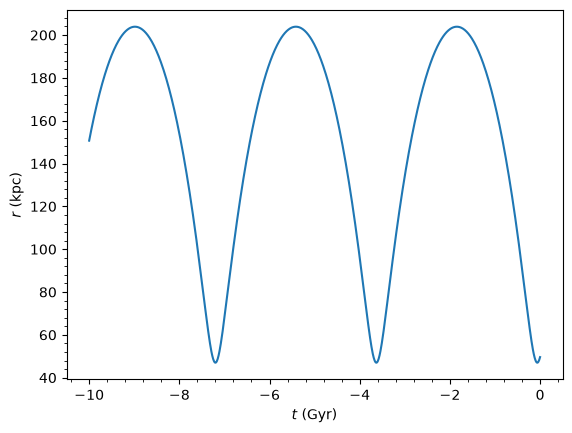

In [10]:
ts = numpy.linspace(0.0, -10.0, 1001) * units.Gyr
o.integrate(ts, mwp)
o.plot(d1="t", d2="r");

The LMC is bound with an apocenter just over 200 kpc.

### Adding dynamical friction (M = 5 x 10^10 Msun)

Now add dynamical friction assuming an LMC mass of 5 x 10^10 Msun:

In [11]:
cdf = ChandrasekharDynamicalFrictionForce(
    GMs=5e10 * units.Msun, rhm=5.0 * units.kpc, dens=mwp
)

# Make a copy of the orbit for the dynamical friction integration
odf = o()
odf.integrate(ts, mwp + cdf)

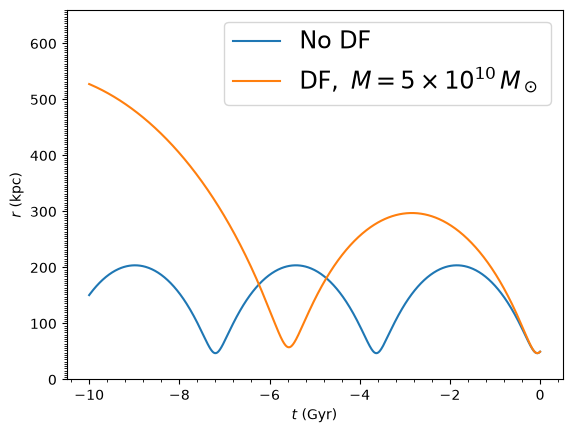

In [12]:
o.plot(d1="t", d2="r", label=r"$\mathrm{No\ DF}$")
odf.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=5\times10^{10}\,M_\odot$"
)
plt.ylim(0.0, 660.0)
plt.legend(fontsize=17.0);

Dynamical friction removes energy from the LMC's orbit, so the past apocenter
is now around 500 kpc rather than 200 kpc, and the orbital period is much longer.

### A more massive LMC (M = 10^11 Msun)

Recent observations suggest the LMC may be even more massive (> 10^11 Msun).
We can change the mass in the existing `ChandrasekharDynamicalFrictionForce`
object without re-solving the Jeans equation (necessary to initialize the dynamical-friction object):

In [13]:
cdf.GMs = 1e11 * units.Msun

odf2 = o()
odf2.integrate(ts, mwp + cdf)

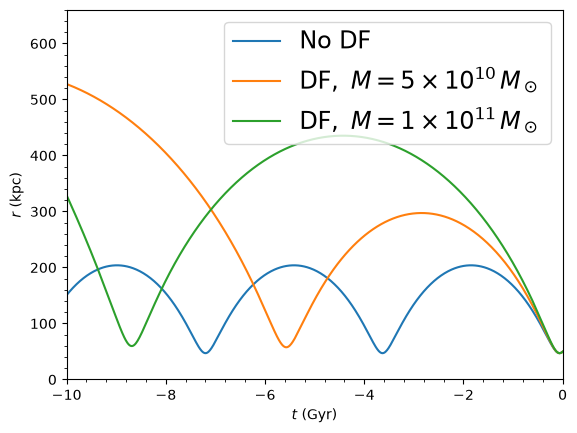

In [14]:
o.plot(d1="t", d2="r", label=r"$\mathrm{No\ DF}$", yrange=[0.0, 660.0])
odf.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=5\times10^{10}\,M_\odot$"
)
odf2.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=1\times10^{11}\,M_\odot$"
)
plt.legend(fontsize=17.0);

With a mass of 10^11 Msun, the LMC barely completes a full orbit over 10 Gyr!

### Future orbit: merging timescale

Let's see what happens in the future with the massive LMC. We flip the sign of
the integration times (limiting to 9 Gyr to avoid numerical issues at very
small radii):

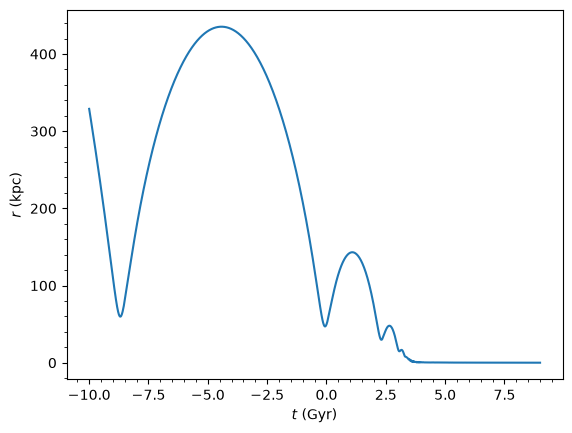

In [15]:
odf2.integrate(numpy.linspace(0.0, 9.0, 1001) * units.Gyr, mwp + cdf)
odf2.plot(d1="t", d2="r");

The LMC merges with the Milky Way in about 4 Gyr after a few more pericenter
passages. Mass loss (not included here) would somewhat increase the merging
timescale, but the merger is inevitable. 

This example also illustrates thhe continuation of an existing orbit integration when 
integrating starting from one of the previous integrations edges. The `integrate` method continues the integration from the last point of the previous integration, so we can seamlessly continue the integration into the future. See [Continuing integrations](./integration_and_plotting.ipynb#Continuing-integrations) for more details.

<div class="alert alert-warning">

**Warning**

When using dynamical friction, if the radius gets very small the
integration can become erroneous, leading to unphysical kicks. Always inspect
the full orbit to check whether a merger has happened.

</div>

## Barycentric acceleration due to the LMC

The LMC is so massive that it pulls the center of the Milky Way towards it,
meaning the Galactocentric reference frame is not truly inertial. We can
account for this using `NonInertialFrameForce`.

Our approach: (1) compute the LMC orbit assuming the MW is at rest, (2) compute
the acceleration at the origin due to the LMC along that orbit, (3) use
`NonInertialFrameForce` with that acceleration.

In [16]:
from galpy.potential import (
    HernquistPotential,
    MovingObjectPotential,
    NonInertialFrameForce,
    evaluateRforces,
    evaluatephitorques,
    evaluatezforces,
)

We already computed the LMC orbit with dynamical friction above. Now we
re-compute it over 10 Gyr backward using the massive LMC setup:

In [17]:
# Re-integrate LMC orbit backward with the heavy LMC
o_lmc = Orbit.from_name("LMC")
ts_back = numpy.linspace(0.0, -10.0, 1001) * units.Gyr
o_lmc.integrate(ts_back, mwp + cdf)

Define the LMC as a `HernquistPotential` and create a `MovingObjectPotential`
that follows its orbit:

In [18]:
# Hernquist potential for LMC: rhm = (1+sqrt(2)) * a, amp = 2 x mass
lmcpot = HernquistPotential(
    amp=2e11 * units.Msun, a=5.0 * units.kpc / (1.0 + numpy.sqrt(2.0))
)
moving_lmcpot = MovingObjectPotential(o_lmc, pot=lmcpot)

Compute the acceleration of the Galactic center due to the LMC by evaluating
the force from `moving_lmcpot` at a small offset from the origin (to avoid
numerical issues in cylindrical coordinates):

In [19]:
loc_origin = 1e-4  # small offset in R
ax = lambda t: evaluateRforces(
    moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False
)
ay = lambda t: (
    evaluatephitorques(moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False)
    / loc_origin
)
az = lambda t: evaluatezforces(
    moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False
)

Set up the `NonInertialFrameForce` with the origin's acceleration. We can pass
the acceleration functions directly: by default (`cinterp=True`),
`NonInertialFrameForce` builds a fast cubic-spline interpolation of them in C
over each orbit integration's time range, so these (relatively expensive)
functions are evaluated only when setting up an integration rather than being
called from C at every integration step. This makes the C orbit integration
much faster and removes the need to manually pre-interpolate the acceleration.

In [20]:
nip = NonInertialFrameForce(a0=[ax, ay, az])

### Effect on the Sun's orbit

Compare the Sun's past orbit with and without the barycentric correction.
When including the non-inertial correction, we must also include the LMC's
gravitational potential (`moving_lmcpot`) to keep the model self-consistent:

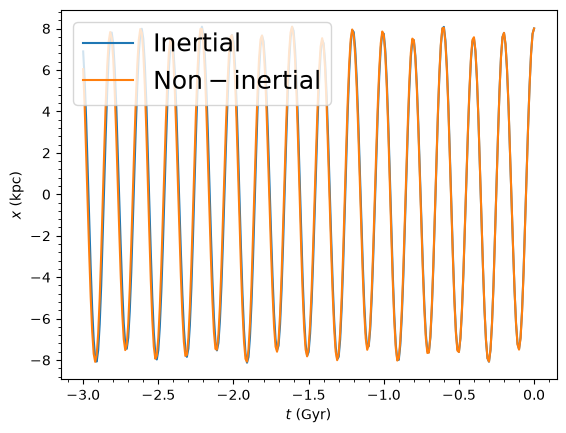

In [21]:
sunts = numpy.linspace(0.0, -3.0, 301) * units.Gyr

osun_inertial = Orbit()
osun_inertial.integrate(sunts, mwp)
osun_inertial.plotx(label=r"$\mathrm{Inertial}$")

osun_noninertial = Orbit()
osun_noninertial.integrate(sunts, mwp + nip + moving_lmcpot)
osun_noninertial.plotx(overplot=True, label=r"$\mathrm{Non-inertial}$")
plt.legend(fontsize=18.0, loc="upper left", framealpha=0.8);

There is essentially no difference for the Sun, because its orbit is close to
the Galactic center where the LMC's pull on the origin is largely cancelled
by the direct attraction to the LMC.

### Effect on a distant dwarf galaxy (Fornax)

For objects orbiting far in the halo, the effect is more significant:

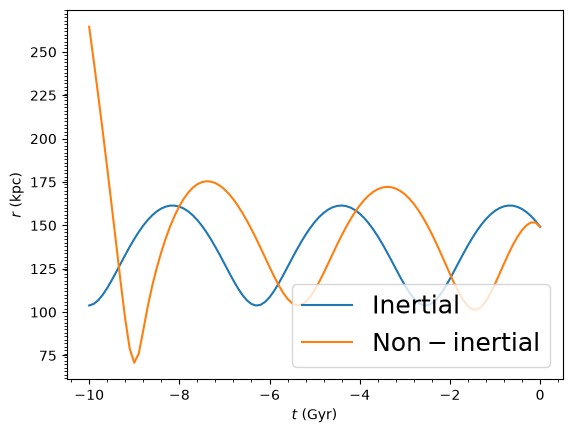

In [22]:
fornaxts = numpy.linspace(0.0, -10.0, 101) * units.Gyr

ofornax_inertial = Orbit.from_name("Fornax")
ofornax_inertial.integrate(fornaxts, mwp)
ofornax_inertial.plotr(label=r"$\mathrm{Inertial}$")

ofornax_noninertial = Orbit.from_name("Fornax")
ofornax_noninertial.integrate(fornaxts, mwp + nip + moving_lmcpot)
ofornax_noninertial.plotr(overplot=True, label=r"$\mathrm{Non-inertial}$")
plt.autoscale()
plt.legend(fontsize=18.0, loc="lower right", framealpha=0.8);

For Fornax, the past orbit differs significantly when the barycentric
acceleration is taken into account. The abrupt change around -8 Gyr is caused
by the LMC's previous pericenter passage in our model.

### Checking the acceleration: displacement, velocity, and force

We can verify the acceleration is realistic by integrating it to get the
displacement and velocity of the MW center, and comparing to the results of
[Vasiliev et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021MNRAS.501.2279V/abstract):

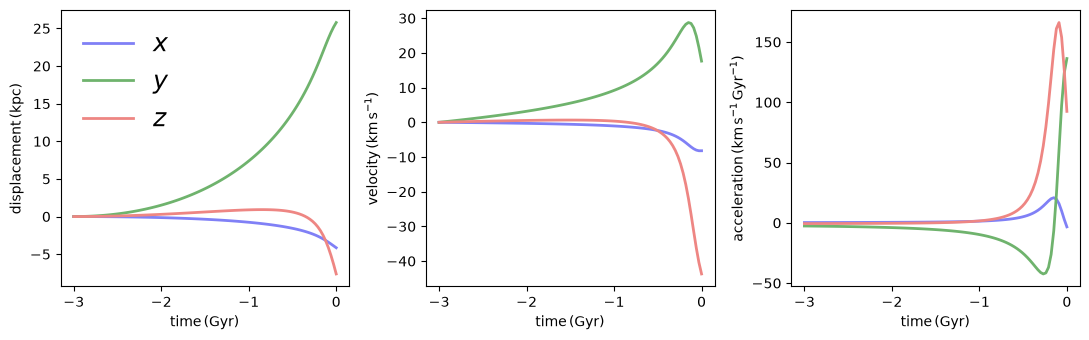

In [23]:
from scipy import integrate

vo, ro = 220.0, 8.0
int_ts_phys = numpy.linspace(-3.0, 0.0, 101)
int_ts = int_ts_phys / conversion.time_in_Gyr(vo, ro)

ax4plot = ax(int_ts)
ay4plot = ay(int_ts)
az4plot = az(int_ts)

vx4plot = integrate.cumulative_trapezoid(ax4plot, x=int_ts, initial=0.0)
vy4plot = integrate.cumulative_trapezoid(ay4plot, x=int_ts, initial=0.0)
vz4plot = integrate.cumulative_trapezoid(az4plot, x=int_ts, initial=0.0)

xx4plot = integrate.cumulative_trapezoid(vx4plot, x=int_ts, initial=0.0)
xy4plot = integrate.cumulative_trapezoid(vy4plot, x=int_ts, initial=0.0)
xz4plot = integrate.cumulative_trapezoid(vz4plot, x=int_ts, initial=0.0)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1)
plt.plot(
    int_ts_phys, xx4plot * ro, color=(0.5, 0.5, 247.0 / 256.0), lw=2.0, label=r"$x$"
)
plt.plot(
    int_ts_phys,
    xy4plot * ro,
    color=(111.0 / 256, 180.0 / 256, 109.0 / 256),
    lw=2.0,
    label=r"$y$",
)
plt.plot(
    int_ts_phys,
    xz4plot * ro,
    color=(239.0 / 256, 135.0 / 256, 132.0 / 256),
    lw=2.0,
    label=r"$z$",
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{displacement}\,(\mathrm{kpc})$")
plt.legend(frameon=False, fontsize=18.0)

plt.subplot(1, 3, 2)
plt.plot(int_ts_phys, vx4plot * vo, color=(0.5, 0.5, 247.0 / 256.0), lw=2.0)
plt.plot(
    int_ts_phys, vy4plot * vo, color=(111.0 / 256, 180.0 / 256, 109.0 / 256), lw=2.0
)
plt.plot(
    int_ts_phys, vz4plot * vo, color=(239.0 / 256, 135.0 / 256, 132.0 / 256), lw=2.0
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{velocity}\,(\mathrm{km\,s}^{-1})$")

plt.subplot(1, 3, 3)
plt.plot(
    int_ts_phys,
    -ax4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(0.5, 0.5, 247.0 / 256.0),
    lw=2.0,
)
plt.plot(
    int_ts_phys,
    -ay4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(111.0 / 256, 180.0 / 256, 109.0 / 256),
    lw=2.0,
)
plt.plot(
    int_ts_phys,
    -az4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(239.0 / 256, 135.0 / 256, 132.0 / 256),
    lw=2.0,
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{acceleration}\,(\mathrm{km\,s}^{-1}\,\mathrm{Gyr}^{-1})$")

plt.tight_layout();

The main trends and magnitudes are consistent with Figure 10 of Vasiliev et al.
(2021), confirming that our simple approximation gives a reasonable estimate of
the Galactocentric reference frame's acceleration.